# `exp_13_16_49` analysis notebook

This notebook focuses on four questions:

1. How does end-to-end latency change by split point and target load?
2. What was the actual achieved server-side RPS versus the configured target RPS?
3. What is the client-side energy cost of each mode / split point?
4. Which partition points look most promising once load is actually triggered?

The notebook builds scenario-level aggregates first, then provides 10+ visualizations plus summary ranking tables.

## Assumptions and notes

- Each row in `experiment_joined.csv` is treated as one client inference sample with synchronized server metrics.
- Scenario-level charts use mean values over each scenario window.
- `load_model_success_rps` is used as the achieved model throughput on the server.
- Even when `target_rps = 0`, the client stream itself still drives about `18-22 RPS` on the server, so the notebook estimates **triggered load** as:
  `estimated_triggered_rps = achieved_model_rps - no_load_baseline_for_that_partition`.
- Client energy is estimated from `client_latest_sampled_power_w * duration_s`, which is approximate because only sampled power is available.
- `full_local` only appears at `target_rps = 0`, so it should be treated as a baseline rather than a loaded comparison point.

In [25]:
! pip install seaborn
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid", context="talk")

In [26]:
RESULT_DIR = Path("exp_13_16_49")

joined = pd.read_csv(RESULT_DIR / "experiment_joined.csv")
plan = pd.read_csv(RESULT_DIR / "experiment_plan.csv")
events = pd.read_csv(RESULT_DIR / "experiment_events.csv")

numeric_columns = [
    "scenario_load_rps_target",
    "client_e2e_latency",
    "client_transfer_time",
    "client_processing_time",
    "client_latest_sampled_power_w",
    "client_latest_power_w",
    "server_total_rps",
    "server_total_success_rps",
    "load_model_success_rps",
    "active_model_avg_queue_time_ms",
    "active_model_avg_compute_infer_ms",
]

for frame in (joined, plan, events):
    for column in frame.columns.intersection(numeric_columns + ["duration_s"]):
        frame[column] = pd.to_numeric(frame[column], errors="coerce")

def normalize_partition(mode, partition_point):
    if mode == "full_server":
        return "full_server"
    if mode == "full_local":
        return "full_local"
    if pd.isna(partition_point) or partition_point == "":
        return "unknown_split"
    return partition_point

joined["partition_label"] = joined.apply(
    lambda row: normalize_partition(row["scenario_mode"], row["scenario_partition_point"]),
    axis=1,
)
plan["partition_label"] = plan.apply(
    lambda row: normalize_partition(row["mode"], row["partition_point"]),
    axis=1,
)
events["partition_label"] = events.apply(
    lambda row: normalize_partition(row["mode"], row["partition_point"]),
    axis=1,
)

partition_order = [
    "full_server",
    "stem",
    "layer1.0",
    "layer1.1",
    "layer2.0",
    "layer2.1",
    "layer3.0",
    "layer3.1",
    "layer4.0",
    "layer4.1",
    "full_local",
]
split_only_order = [label for label in partition_order if label not in {"full_server", "full_local"}]

joined[[
    "scenario_id",
    "scenario_mode",
    "partition_label",
    "scenario_load_rps_target",
    "client_e2e_latency",
    "load_model_success_rps",
    "client_latest_sampled_power_w",
]].head()

,scenario_id,scenario_mode,partition_label,scenario_load_rps_target,client_e2e_latency,load_model_success_rps,client_latest_sampled_power_w
0,1,full_server,full_server,0.0,0.036169,NaN,3.317
1,1,full_server,full_server,0.0,0.035994,NaN,3.317
2,1,full_server,full_server,0.0,0.035883,NaN,3.317
3,1,full_server,full_server,0.0,0.039401,NaN,3.317
4,1,full_server,full_server,0.0,0.037219,22.0,3.317


In [27]:
scenario_summary = (
    joined
    .groupby(
        [
            "experiment_id",
            "scenario_id",
            "scenario_mode",
            "partition_label",
            "scenario_load_rps_target",
            "scenario_load_model_name",
        ],
        dropna=False,
    )
    .agg(
        request_count=("client_request_id", "count"),
        mean_e2e_latency_s=("client_e2e_latency", "mean"),
        p95_e2e_latency_s=("client_e2e_latency", lambda s: s.quantile(0.95)),
        mean_transfer_time_s=("client_transfer_time", "mean"),
        mean_processing_time_s=("client_processing_time", "mean"),
        mean_client_power_w=("client_latest_sampled_power_w", "mean"),
        mean_client_power_alt_w=("client_latest_power_w", "mean"),
        mean_actual_model_rps=("load_model_success_rps", "mean"),
        mean_server_total_rps=("server_total_success_rps", "mean"),
        mean_queue_time_ms=("active_model_avg_queue_time_ms", "mean"),
        mean_infer_time_ms=("active_model_avg_compute_infer_ms", "mean"),
    )
    .reset_index()
    .rename(
        columns={
            "scenario_mode": "mode",
            "scenario_load_rps_target": "target_rps",
            "scenario_load_model_name": "load_model_name",
        }
    )
)

duration_lookup = (
    plan[["scenario_id", "duration_s"]]
    .drop_duplicates(subset=["scenario_id"])
)

scenario_summary = scenario_summary.merge(duration_lookup, on="scenario_id", how="left")
scenario_summary["duration_s"] = scenario_summary["duration_s"].fillna(25.0)

scenario_summary["client_request_rate_rps"] = scenario_summary["request_count"] / scenario_summary["duration_s"]
scenario_summary["scenario_energy_j"] = scenario_summary["mean_client_power_w"] * scenario_summary["duration_s"]
scenario_summary["energy_per_request_mj"] = (
    scenario_summary["scenario_energy_j"] * 1000 / scenario_summary["request_count"]
)

baseline_rps = (
    scenario_summary.loc[scenario_summary["target_rps"] == 0, ["partition_label", "mean_actual_model_rps"]]
    .drop_duplicates(subset=["partition_label"])
    .set_index("partition_label")["mean_actual_model_rps"]
)

scenario_summary["baseline_model_rps"] = scenario_summary["partition_label"].map(baseline_rps).fillna(0.0)
scenario_summary["estimated_triggered_rps"] = np.where(
    scenario_summary["target_rps"] > 0,
    (scenario_summary["mean_actual_model_rps"] - scenario_summary["baseline_model_rps"]).clip(lower=0),
    0.0,
)
scenario_summary["attainment_ratio"] = np.where(
    scenario_summary["target_rps"] > 0,
    scenario_summary["estimated_triggered_rps"] / scenario_summary["target_rps"],
    np.nan,
)

scenario_summary["partition_label"] = pd.Categorical(
    scenario_summary["partition_label"],
    categories=partition_order,
    ordered=True,
)
scenario_summary = scenario_summary.sort_values(["target_rps", "partition_label"]).reset_index(drop=True)

scenario_summary[[
    "mode",
    "partition_label",
    "target_rps",
    "mean_e2e_latency_s",
    "mean_actual_model_rps",
    "estimated_triggered_rps",
    "attainment_ratio",
    "mean_client_power_w",
    "scenario_energy_j",
]].round(4)

,mode,partition_label,target_rps,mean_e2e_latency_s,mean_actual_model_rps,estimated_triggered_rps,attainment_ratio,mean_client_power_w,scenario_energy_j
0,full_server,full_server,0.0,0.0375,22.3477,0.0000,NaN,3.5877,89.6922
1,split,stem,0.0,0.0397,21.4478,0.0000,NaN,3.4247,85.6180
2,split,layer1.0,0.0,0.0415,20.5380,0.0000,NaN,3.6436,91.0907
3,split,layer1.1,0.0,0.0432,19.6184,0.0000,NaN,3.9555,98.8881
4,split,layer2.0,0.0,0.0411,20.8705,0.0000,NaN,4.1870,104.6743
5,split,layer2.1,0.0,0.0436,19.4863,0.0000,NaN,4.8630,121.5741
6,split,layer3.0,0.0,0.0418,20.3772,0.0000,NaN,4.9638,124.0938
7,split,layer3.1,0.0,0.0421,20.1250,0.0000,NaN,5.2471,131.1770
8,split,layer4.0,0.0,0.0496,17.6882,0.0000,NaN,5.4685,136.7126
9,split,layer4.1,0.0,0.0470,18.4813,0.0000,NaN,6.2349,155.8725


In [28]:
def ordered_pivot(source_df, metric, columns_order, index_col="target_rps"):
    pivot = source_df.pivot(index=index_col, columns="partition_label", values=metric).sort_index()
    valid_columns = [column for column in columns_order if column in pivot.columns]
    return pivot.reindex(columns=valid_columns)

def plot_heatmap(source_df, metric, title, fmt, cmap, columns_order, center=None):
    pivot = ordered_pivot(source_df, metric, columns_order)
    plt.figure(figsize=(14, max(4, 0.9 * len(pivot.index) + 1)))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        linewidths=0.5,
        cbar_kws={"shrink": 0.9},
        center=center,
    )
    plt.title(title)
    plt.xlabel("Partition point / layer name")
    plt.ylabel("Target RPS")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()
    return pivot

def minmax_score(series, higher_is_better=True):
    series = series.astype(float)
    if series.nunique(dropna=True) <= 1:
        return pd.Series(1.0, index=series.index)
    scaled = (series - series.min()) / (series.max() - series.min())
    return scaled if higher_is_better else 1 - scaled

## Visual analysis

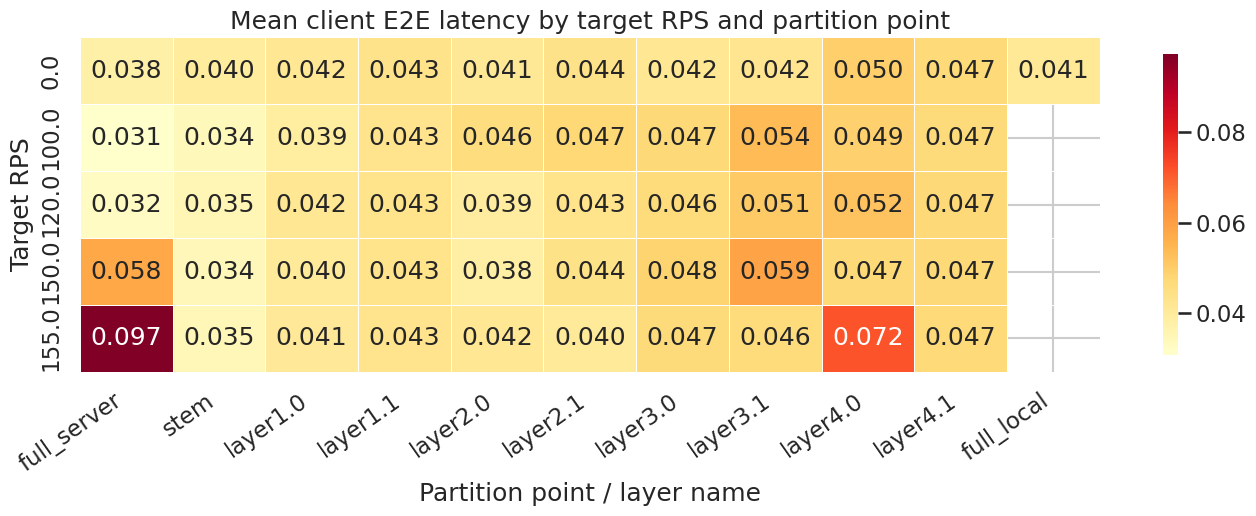

partition_label,full_server,stem,layer1.0,layer1.1,layer2.0,layer2.1,layer3.0,layer3.1,layer4.0,layer4.1,full_local
target_rps,,,,,,,,,,,
0.0,0.037513,0.039671,0.041504,0.043235,0.041147,0.043638,0.041760,0.042139,0.049616,0.046989,0.041017
100.0,0.030594,0.033786,0.039134,0.042789,0.045567,0.047390,0.047113,0.053675,0.048984,0.046659,NaN
120.0,0.032484,0.035091,0.041684,0.043040,0.039415,0.043021,0.046321,0.050677,0.052035,0.047222,NaN
150.0,0.057784,0.034399,0.040310,0.043018,0.037946,0.043761,0.048500,0.058878,0.047105,0.047042,NaN
155.0,0.097380,0.034522,0.040708,0.042794,0.041551,0.040280,0.046641,0.046124,0.071792,0.046899,NaN


In [29]:
# 1. Mean E2E latency heatmap.
plot_heatmap(
    scenario_summary,
    metric="mean_e2e_latency_s",
    title="Mean client E2E latency by target RPS and partition point",
    fmt=".3f",
    cmap="YlOrRd",
    columns_order=partition_order,
)

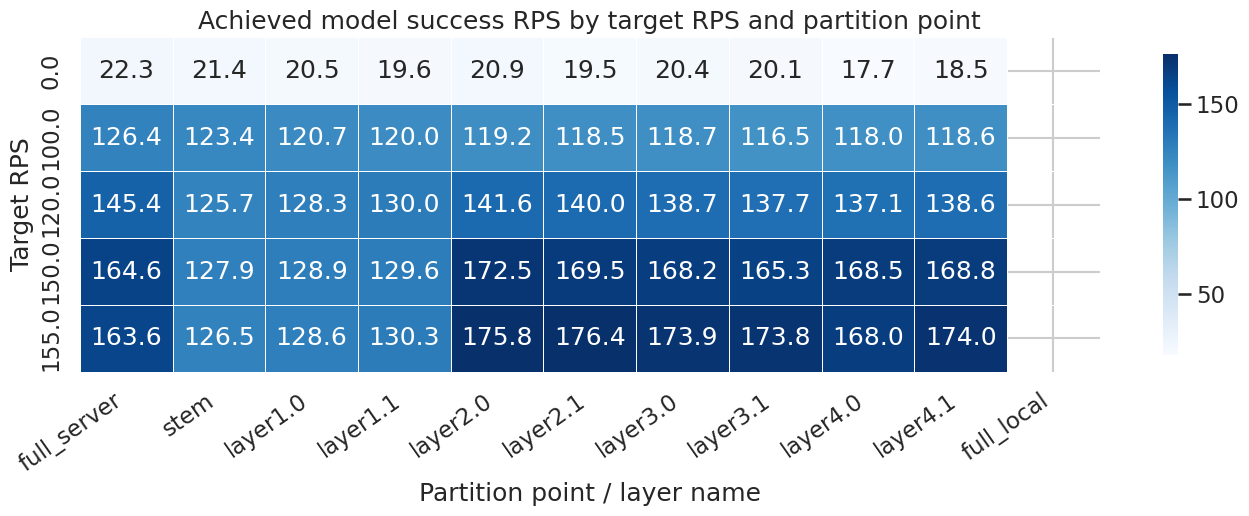

partition_label,full_server,stem,layer1.0,layer1.1,layer2.0,layer2.1,layer3.0,layer3.1,layer4.0,layer4.1,full_local
target_rps,,,,,,,,,,,
0.0,22.347748,21.447818,20.538000,19.618449,20.870518,19.486316,20.377246,20.125000,17.688222,18.481319,NaN
100.0,126.398425,123.364975,120.707317,120.004065,119.153348,118.456140,118.684096,116.495098,117.997743,118.645788,NaN
120.0,145.400651,125.686308,128.295276,130.006061,141.599620,139.987500,138.705752,137.690647,137.133172,138.606264,NaN
150.0,164.641161,127.898649,128.931373,129.569647,172.469091,169.531250,168.180365,165.336043,168.522976,168.814978,NaN
155.0,163.575107,126.517588,128.617934,130.325866,175.779297,176.397706,173.888889,173.803456,168.013115,174.010846,NaN


In [30]:
# 2. Achieved total model RPS on the server.
plot_heatmap(
    scenario_summary,
    metric="mean_actual_model_rps",
    title="Achieved model success RPS by target RPS and partition point",
    fmt=".1f",
    cmap="Blues",
    columns_order=partition_order,
)

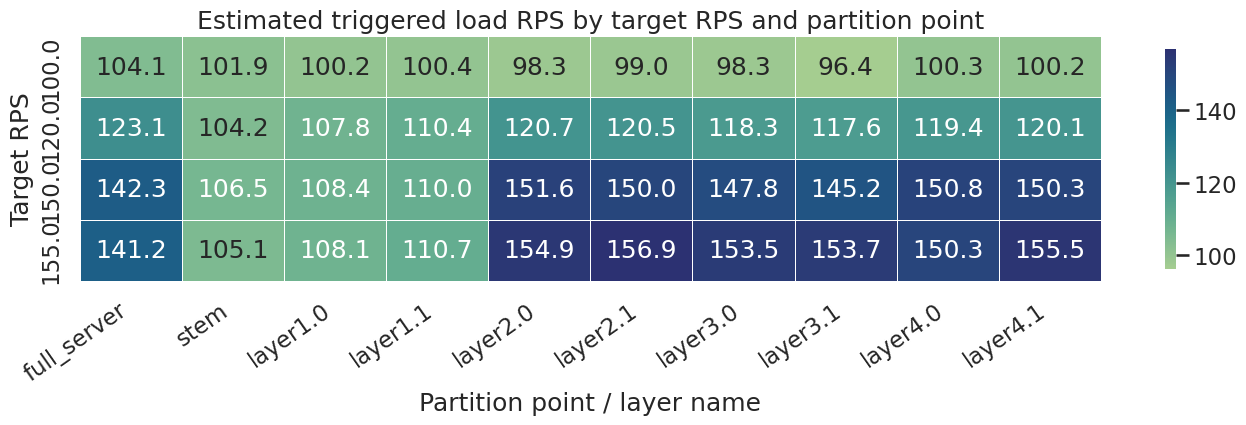

partition_label,full_server,stem,layer1.0,layer1.1,layer2.0,layer2.1,layer3.0,layer3.1,layer4.0,layer4.1
target_rps,,,,,,,,,,
100.0,104.050677,101.917158,100.169317,100.385616,98.282830,98.969825,98.306850,96.370098,100.309521,100.164470
120.0,123.052904,104.238491,107.757276,110.387612,120.729103,120.501184,118.328507,117.565647,119.444950,120.124945
150.0,142.293413,106.450831,108.393373,109.951198,151.598573,150.044934,147.803120,145.211043,150.834754,150.333659
155.0,141.227360,105.069770,108.079934,110.707417,154.908779,156.911390,153.511643,153.678456,150.324893,155.529527


In [31]:
# 3. Estimated triggered load after subtracting the no-load baseline per partition.
loaded_only = scenario_summary.query("target_rps > 0 and mode != 'full_local'").copy()

plot_heatmap(
    loaded_only,
    metric="estimated_triggered_rps",
    title="Estimated triggered load RPS by target RPS and partition point",
    fmt=".1f",
    cmap="crest",
    columns_order=[label for label in partition_order if label != "full_local"],
)

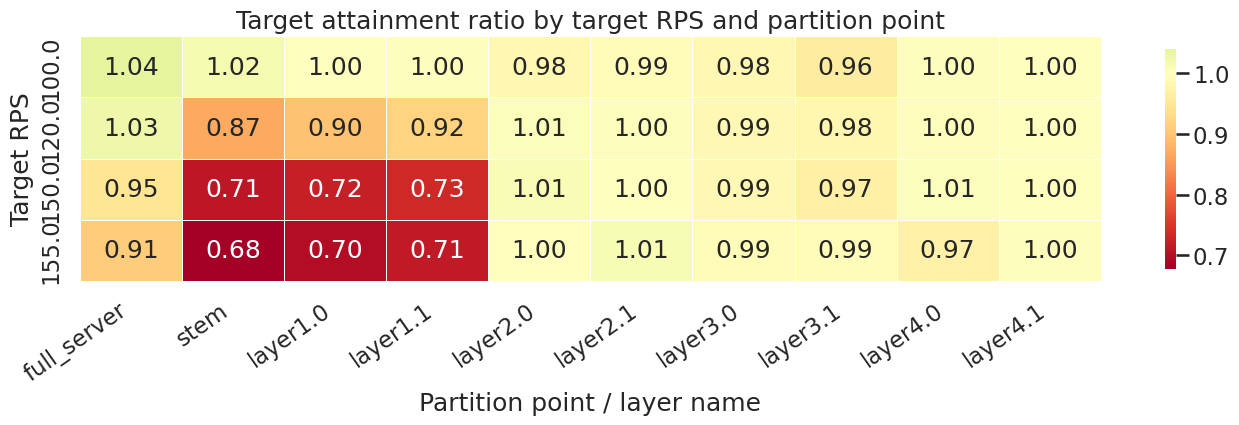

partition_label,full_server,stem,layer1.0,layer1.1,layer2.0,layer2.1,layer3.0,layer3.1,layer4.0,layer4.1
target_rps,,,,,,,,,,
100.0,1.040507,1.019172,1.001693,1.003856,0.982828,0.989698,0.983069,0.963701,1.003095,1.001645
120.0,1.025441,0.868654,0.897977,0.919897,1.006076,1.004177,0.986071,0.979714,0.995375,1.001041
150.0,0.948623,0.709672,0.722622,0.733008,1.010657,1.000300,0.985354,0.968074,1.005565,1.002224
155.0,0.911144,0.677869,0.697290,0.714241,0.999411,1.012332,0.990398,0.991474,0.969838,1.003416


In [32]:
# 4. How closely each scenario met its target load.
plot_heatmap(
    loaded_only,
    metric="attainment_ratio",
    title="Target attainment ratio by target RPS and partition point",
    fmt=".2f",
    cmap="RdYlGn",
    columns_order=[label for label in partition_order if label != "full_local"],
    center=1.0,
)

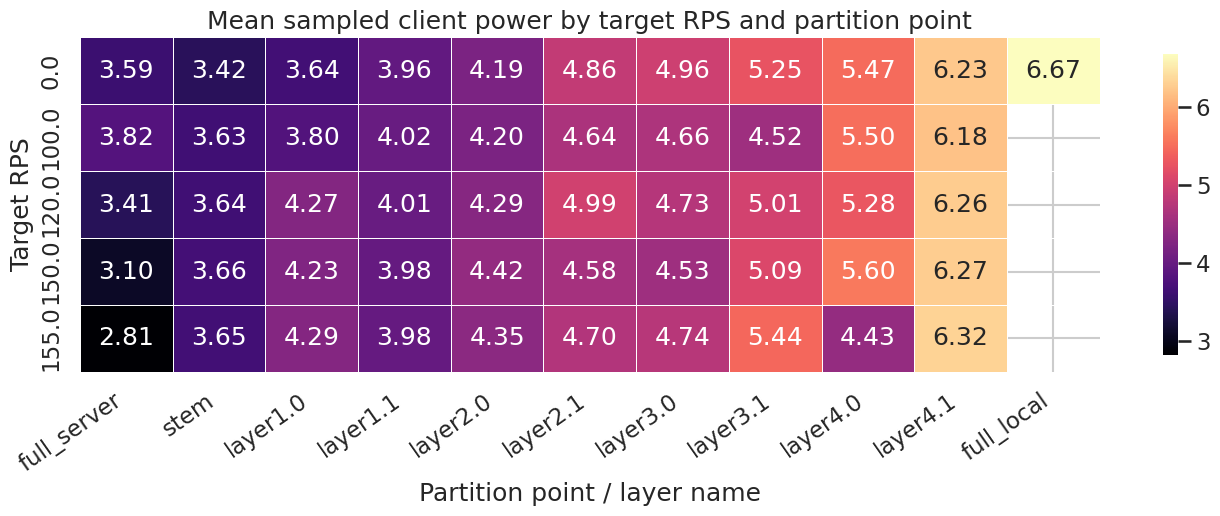

partition_label,full_server,stem,layer1.0,layer1.1,layer2.0,layer2.1,layer3.0,layer3.1,layer4.0,layer4.1,full_local
target_rps,,,,,,,,,,,
0.0,3.587689,3.424718,3.643626,3.955522,4.186973,4.862965,4.963753,5.247082,5.468506,6.234898,6.672631
100.0,3.823100,3.629133,3.803803,4.017533,4.199899,4.641455,4.660511,4.523685,5.499376,6.178614,NaN
120.0,3.412271,3.640978,4.274273,4.011942,4.293587,4.992368,4.729515,5.010351,5.282856,6.262399,NaN
150.0,3.096765,3.660364,4.234345,3.975201,4.417206,4.581652,4.529526,5.091016,5.596350,6.266373,NaN
155.0,2.813335,3.646320,4.289696,3.977864,4.349840,4.699735,4.743496,5.439000,4.432644,6.316816,NaN


In [33]:
# 5. Client-side power draw by partition point.
plot_heatmap(
    scenario_summary,
    metric="mean_client_power_w",
    title="Mean sampled client power by target RPS and partition point",
    fmt=".2f",
    cmap="magma",
    columns_order=partition_order,
)

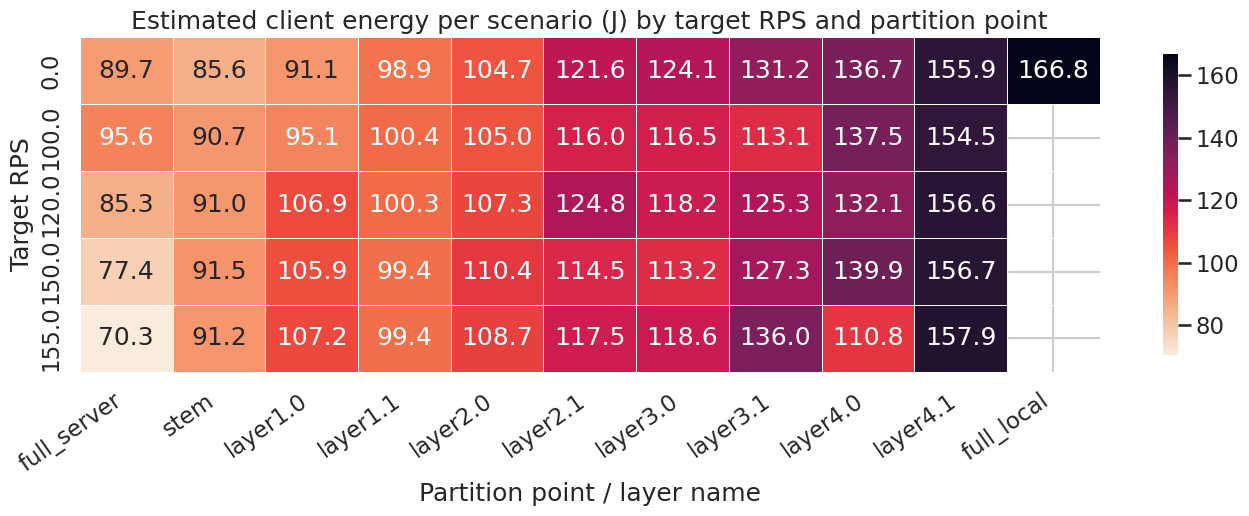

partition_label,full_server,stem,layer1.0,layer1.1,layer2.0,layer2.1,layer3.0,layer3.1,layer4.0,layer4.1,full_local
target_rps,,,,,,,,,,,
0.0,89.692218,85.617957,91.090661,98.888061,104.674327,121.574126,124.093824,131.177038,136.712641,155.872451,166.815787
100.0,95.577500,90.728333,95.095065,100.438323,104.997479,116.036379,116.512772,113.092131,137.484403,154.465356,NaN
120.0,85.306786,91.024455,106.856814,100.298544,107.339684,124.809211,118.237876,125.258776,132.071403,156.559967,NaN
150.0,77.419125,91.509102,105.858619,99.380030,110.430162,114.541309,113.238140,127.275396,139.908750,156.659328,NaN
155.0,70.333368,91.157988,107.242389,99.446600,108.746004,117.493371,118.587392,135.975000,110.816088,157.920400,NaN


In [34]:
# 6. Estimated client energy per scenario window.
plot_heatmap(
    scenario_summary,
    metric="scenario_energy_j",
    title="Estimated client energy per scenario (J) by target RPS and partition point",
    fmt=".1f",
    cmap="rocket_r",
    columns_order=partition_order,
)

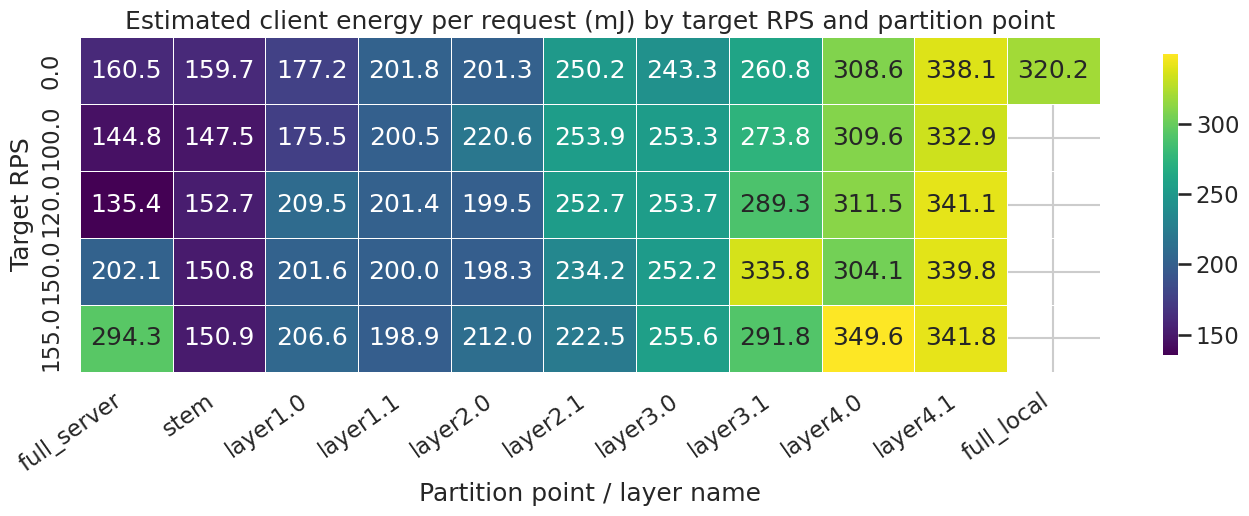

partition_label,full_server,stem,layer1.0,layer1.1,layer2.0,layer2.1,layer3.0,layer3.1,layer4.0,layer4.1,full_local
target_rps,,,,,,,,,,,
0.0,160.451195,159.734995,177.219186,201.812370,201.296783,250.152522,243.321223,260.789340,308.606413,338.118115,320.183852
100.0,144.814394,147.525745,175.452149,200.475695,220.582939,253.908925,253.288634,273.830825,309.649557,332.899473,NaN
120.0,135.407596,152.725595,209.523164,201.402699,199.516141,252.650224,253.729347,289.281238,311.489159,341.089253,NaN
150.0,202.138708,150.756346,201.635465,199.959819,198.258818,234.235805,252.200758,335.818986,304.149457,339.825006,NaN
155.0,294.281875,150.923822,206.632735,198.893200,211.980514,222.525324,255.576276,291.791845,349.577566,341.819049,NaN


In [35]:
# 7. Estimated client energy cost per client request.
plot_heatmap(
    scenario_summary,
    metric="energy_per_request_mj",
    title="Estimated client energy per request (mJ) by target RPS and partition point",
    fmt=".1f",
    cmap="viridis",
    columns_order=partition_order,
)

/tmp/ipykernel_327921/1109753897.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for partition_name, frame in loaded_only.groupby("partition_label"):


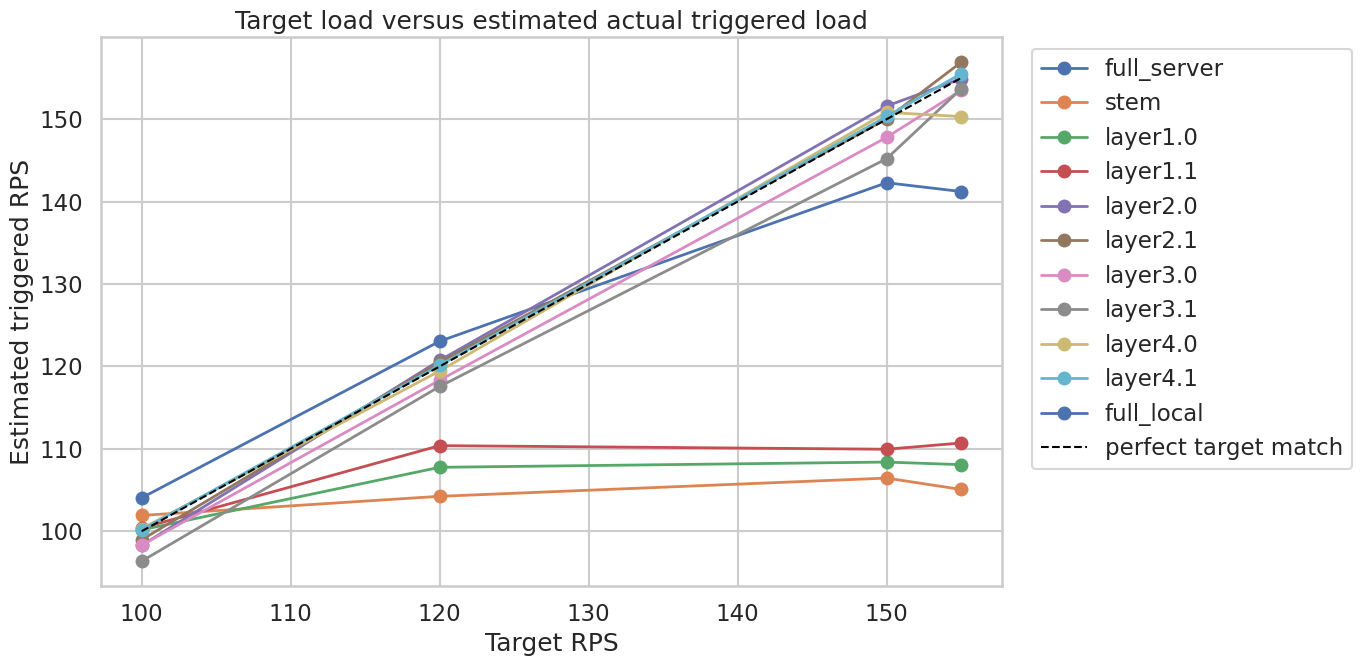

In [36]:
# 8. Target RPS versus estimated actual triggered RPS for each split point.
plt.figure(figsize=(14, 7))
for partition_name, frame in loaded_only.groupby("partition_label"):
    frame = frame.sort_values("target_rps")
    plt.plot(
        frame["target_rps"],
        frame["estimated_triggered_rps"],
        marker="o",
        linewidth=2,
        label=str(partition_name),
    )

x_min = loaded_only["target_rps"].min()
x_max = loaded_only["target_rps"].max()
plt.plot([x_min, x_max], [x_min, x_max], linestyle="--", color="black", linewidth=1.5, label="perfect target match")
plt.title("Target load versus estimated actual triggered load")
plt.xlabel("Target RPS")
plt.ylabel("Estimated triggered RPS")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

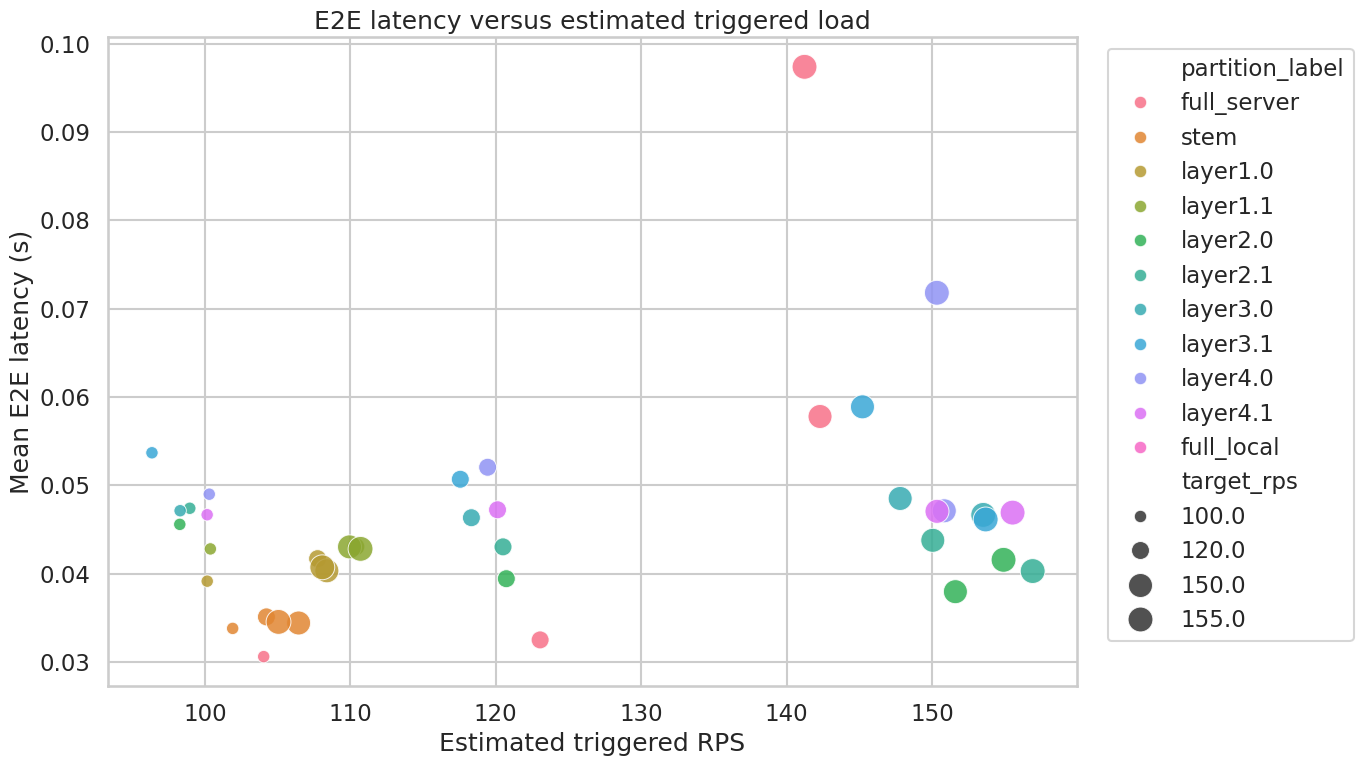

In [37]:
# 9. How actual load affects latency.
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=loaded_only,
    x="estimated_triggered_rps",
    y="mean_e2e_latency_s",
    hue="partition_label",
    size="target_rps",
    sizes=(80, 320),
    alpha=0.85,
)
plt.title("E2E latency versus estimated triggered load")
plt.xlabel("Estimated triggered RPS")
plt.ylabel("Mean E2E latency (s)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

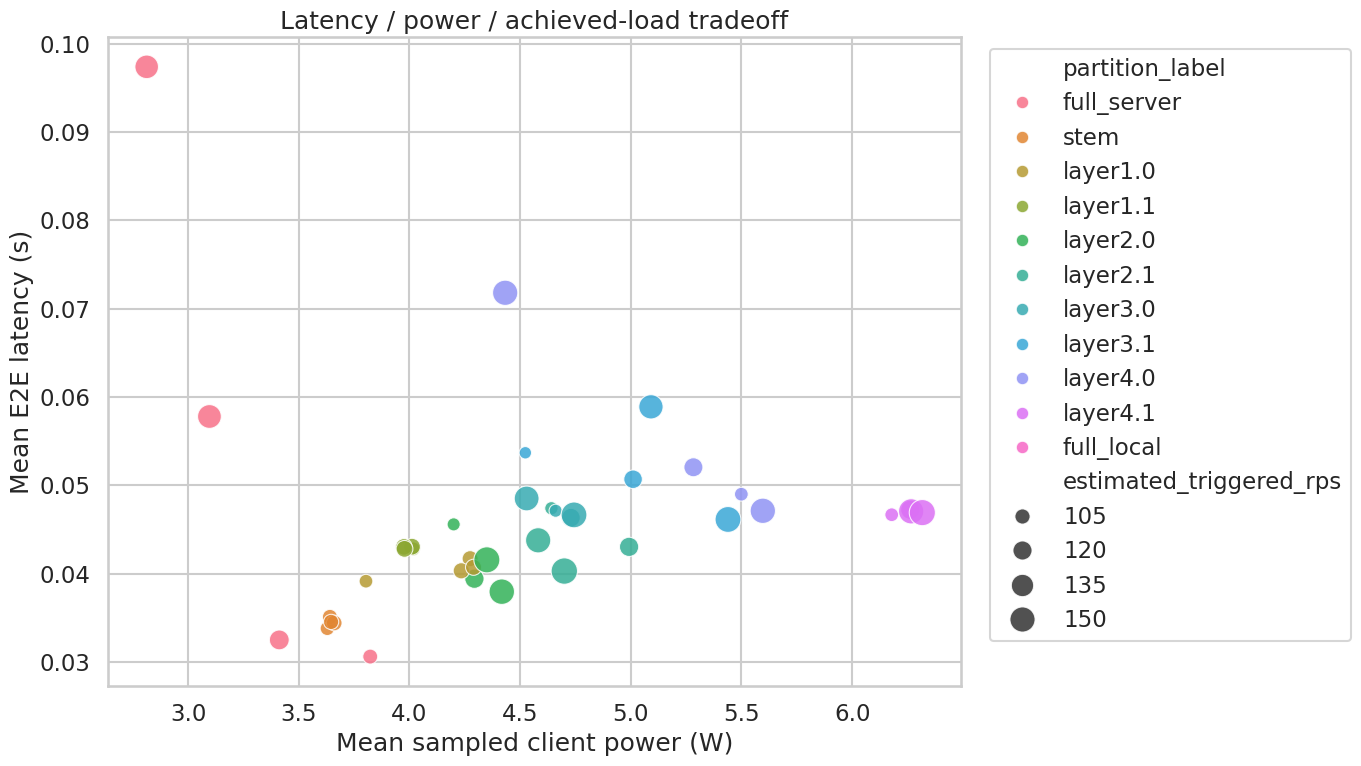

In [38]:
# 10. Three-way tradeoff: latency, power, and achieved load.
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=loaded_only,
    x="mean_client_power_w",
    y="mean_e2e_latency_s",
    hue="partition_label",
    size="estimated_triggered_rps",
    sizes=(80, 360),
    alpha=0.85,
)
plt.title("Latency / power / achieved-load tradeoff")
plt.xlabel("Mean sampled client power (W)")
plt.ylabel("Mean E2E latency (s)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

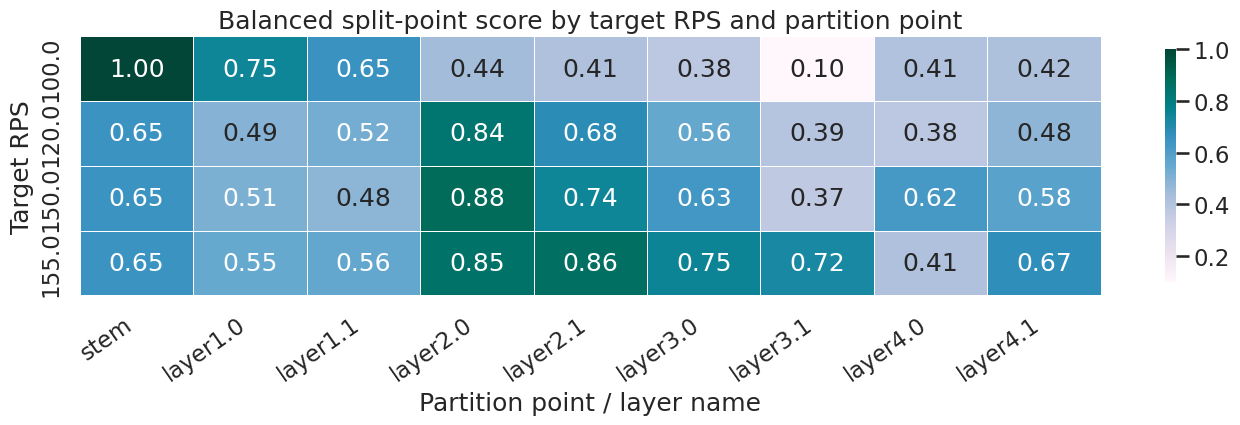

Best raw latency by target (includes full_server if it wins):


,target_rps,mode,partition_label,mean_e2e_latency_s,estimated_triggered_rps,attainment_ratio
0,100.0,full_server,full_server,0.0306,104.0507,1.0405
1,120.0,full_server,full_server,0.0325,123.0529,1.0254
2,150.0,split,stem,0.0344,106.4508,0.7097
3,155.0,split,stem,0.0345,105.0698,0.6779


Best feasible split by target (requires attainment >= 0.95):


,target_rps,partition_label,mean_e2e_latency_s,estimated_triggered_rps,attainment_ratio,mean_client_power_w
0,100.0,stem,0.0338,101.9172,1.0192,3.6291
1,120.0,layer2.0,0.0394,120.7291,1.0061,4.2936
2,150.0,layer2.0,0.0379,151.5986,1.0107,4.4172
3,155.0,layer2.1,0.0403,156.9114,1.0123,4.6997


Best balanced split by target (heuristic score: latency 50%, attainment 35%, power 15%):


,target_rps,partition_label,balanced_score,mean_e2e_latency_s,estimated_triggered_rps,attainment_ratio,mean_client_power_w
0,100.0,stem,1.0000,0.0338,101.9172,1.0192,3.6291
1,120.0,layer2.0,0.8351,0.0394,120.7291,1.0061,4.2936
2,150.0,layer2.0,0.8840,0.0379,151.5986,1.0107,4.4172
3,155.0,layer2.1,0.8636,0.0403,156.9114,1.0123,4.6997


In [39]:
split_loaded = scenario_summary.query("mode == 'split' and target_rps > 0").copy()

split_loaded["latency_score"] = split_loaded.groupby("target_rps")["mean_e2e_latency_s"].transform(
    lambda series: minmax_score(series, higher_is_better=False)
)
split_loaded["attainment_score"] = split_loaded.groupby("target_rps")["attainment_ratio"].transform(
    lambda series: minmax_score(series.clip(upper=1.05), higher_is_better=True)
)
split_loaded["power_score"] = split_loaded.groupby("target_rps")["mean_client_power_w"].transform(
    lambda series: minmax_score(series, higher_is_better=False)
)

split_loaded["balanced_score"] = (
    0.50 * split_loaded["latency_score"]
    + 0.35 * split_loaded["attainment_score"]
    + 0.15 * split_loaded["power_score"]
)

plot_heatmap(
    split_loaded,
    metric="balanced_score",
    title="Balanced split-point score by target RPS and partition point",
    fmt=".2f",
    cmap="PuBuGn",
    columns_order=split_only_order,
)

best_latency_any = (
    loaded_only.sort_values(["target_rps", "mean_e2e_latency_s"])
    .groupby("target_rps", as_index=False)
    .first()[["target_rps", "mode", "partition_label", "mean_e2e_latency_s", "estimated_triggered_rps", "attainment_ratio"]]
)

best_feasible_split = (
    split_loaded.query("attainment_ratio >= 0.95")
    .sort_values(["target_rps", "mean_e2e_latency_s"])
    .groupby("target_rps", as_index=False)
    .first()[["target_rps", "partition_label", "mean_e2e_latency_s", "estimated_triggered_rps", "attainment_ratio", "mean_client_power_w"]]
)

best_balanced_split = (
    split_loaded.sort_values(["target_rps", "balanced_score"], ascending=[True, False])
    .groupby("target_rps", as_index=False)
    .first()[["target_rps", "partition_label", "balanced_score", "mean_e2e_latency_s", "estimated_triggered_rps", "attainment_ratio", "mean_client_power_w"]]
)

print("Best raw latency by target (includes full_server if it wins):")
display(best_latency_any.round(4))

print("Best feasible split by target (requires attainment >= 0.95):")
display(best_feasible_split.round(4))

print("Best balanced split by target (heuristic score: latency 50%, attainment 35%, power 15%):")
display(best_balanced_split.round(4))

## Expected takeaways from this dataset

Based on the current `exp_13_16_49` data, the main story is likely:

- `full_server` is strongest for pure latency at moderate target load, but it degrades sharply by the highest targets.
- `stem` is the lowest-latency split under heavy target load, but it does **not** absorb the full requested load once targets get high.
- `layer2.0` looks like the strongest practical split around `120-150 target RPS` because it keeps latency low while still reaching the target load.
- `layer2.1` becomes especially attractive around `155 target RPS` because it reaches the target and keeps latency close to the best loaded alternatives.
- Very deep splits such as `layer4.0` and `layer4.1` increase client-side power substantially, and the extra client cost often does not buy better latency than the stronger mid-network split points.

Use the feasibility table and the balanced-score heatmap together: the first answers "which split point actually meets the load?" and the second answers "which one is the best compromise?"